# FraudGuard — 04: Random Forest

`class_weight='balanced'` ile eğitilen Random Forest modeli. Baseline Logistic Regression ile karşılaştırma yapılır.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
import json
import joblib
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score, roc_curve,
    average_precision_score, precision_recall_curve,
    precision_score, recall_score, f1_score
)

np.random.seed(42)

PROCESSED_DIR = Path('../data/processed')
MODELS_DIR    = Path('../models')
METRICS_DIR   = Path('../results/metrics')
FIGURES_DIR   = Path('../results/figures')

In [2]:
with open('../config/model_params.yaml', 'r') as f:
    cfg = yaml.safe_load(f)

RF_CFG = cfg['random_forest']
print('Random Forest config:', RF_CFG)

Random Forest config: {'random_state': 42, 'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'class_weight': 'balanced'}


## 1. Veriyi Yükle

In [3]:
X_train = pd.read_csv(PROCESSED_DIR / 'X_train_scaled.csv')
X_test  = pd.read_csv(PROCESSED_DIR / 'X_test_scaled.csv')
y_train = pd.read_csv(PROCESSED_DIR / 'y_train.csv').squeeze()
y_test  = pd.read_csv(PROCESSED_DIR / 'y_test.csv').squeeze()

print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')
print(f'Train fraud: {y_train.sum()} ({y_train.mean():.4%})')
print(f'Test  fraud: {y_test.sum()}  ({y_test.mean():.4%})')

X_train: (227845, 30)  |  X_test: (56962, 30)
Train fraud: 394 (0.1729%)
Test  fraud: 98  (0.1720%)


## 2. Model Eğitimi

In [4]:
model = RandomForestClassifier(**RF_CFG)

model.fit(X_train, y_train)
print('Model eğitildi.')
print(f'Ağaç sayısı       : {model.n_estimators}')
print(f'class_weight      : {model.class_weight}')
print(f'Özellik sayısı    : {model.n_features_in_}')

Model eğitildi.
Ağaç sayısı       : 100
class_weight      : balanced
Özellik sayısı    : 30


## 3. Tahmin

In [5]:
y_pred       = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print('Tahmin tamamlandı.')
print(f'Tahmin edilen fraud sayısı: {y_pred.sum()}')
print(f'Gerçek fraud sayısı:        {y_test.sum()}')

Tahmin tamamlandı.
Tahmin edilen fraud sayısı: 76
Gerçek fraud sayısı:        98


## 4. Metrikler

In [6]:
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_pred_proba)
pr_auc    = average_precision_score(y_test, y_pred_proba)

print('=== Random Forest — Test Seti Metrikleri ===')
print(f'Precision : {precision:.4f}')
print(f'Recall    : {recall:.4f}')
print(f'F1        : {f1:.4f}')
print(f'ROC-AUC   : {roc_auc:.4f}')
print(f'PR-AUC    : {pr_auc:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Normal', 'Fraud']))

=== Random Forest — Test Seti Metrikleri ===
Precision : 0.9605
Recall    : 0.7449
F1        : 0.8391
ROC-AUC   : 0.9529
PR-AUC    : 0.8539

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.96      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962



In [7]:
with open(METRICS_DIR / '05_baseline_metrics.json', 'r') as f:
    lr_metrics = json.load(f)

comparison = pd.DataFrame([
    {
        'Model'    : 'Logistic Regression (baseline)',
        'Precision': lr_metrics['precision'],
        'Recall'   : lr_metrics['recall'],
        'F1'       : lr_metrics['f1'],
        'ROC-AUC'  : lr_metrics['roc_auc'],
        'PR-AUC'   : lr_metrics['pr_auc'],
    },
    {
        'Model'    : 'Random Forest (balanced)',
        'Precision': round(float(precision), 4),
        'Recall'   : round(float(recall),    4),
        'F1'       : round(float(f1),        4),
        'ROC-AUC'  : round(float(roc_auc),   4),
        'PR-AUC'   : round(float(pr_auc),    4),
    },
])

comparison = comparison.set_index('Model')
print('=== Model Karşılaştırması ===')
print(comparison.to_string())

=== Model Karşılaştırması ===
                                Precision  Recall      F1  ROC-AUC  PR-AUC
Model                                                                     
Logistic Regression (baseline)     0.8267  0.6327  0.7168   0.9605  0.7414
Random Forest (balanced)           0.9605  0.7449  0.8391   0.9529  0.8539


## 5. Confusion Matrix

TN=56,861  FP=3  FN=25  TP=73


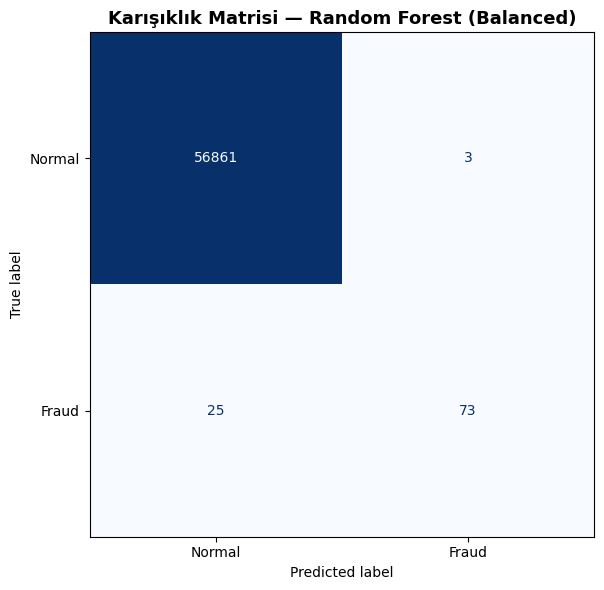

Saved: 09_rf_confusion_matrix.png


In [8]:
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Fraud'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Karışıklık Matrisi — Random Forest (Balanced)', fontsize=13, fontweight='bold')

tn, fp, fn, tp = cm.ravel()
print(f'TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '09_rf_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 09_rf_confusion_matrix.png')

## 6. ROC ve PR Eğrileri

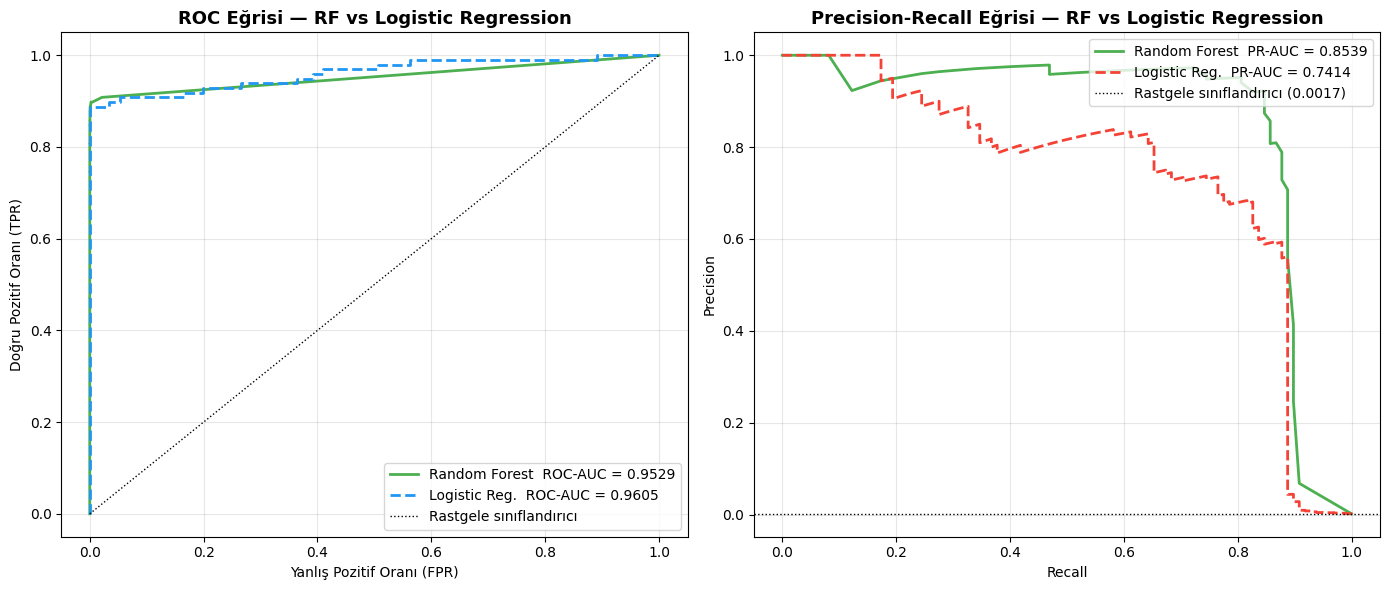

Saved: 10_rf_roc_pr_curves.png


In [9]:
# Load LR model for comparison curves
lr_model         = joblib.load(MODELS_DIR / 'logistic_regression.pkl')
lr_pred_proba    = lr_model.predict_proba(X_test)[:, 1]
lr_roc_auc       = lr_metrics['roc_auc']
lr_pr_auc        = lr_metrics['pr_auc']

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba)
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_pred_proba)
prec_rf, rec_rf, _ = precision_recall_curve(y_test, y_pred_proba)
prec_lr, rec_lr, _ = precision_recall_curve(y_test, lr_pred_proba)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC
axes[0].plot(fpr_rf, tpr_rf, color='#4CAF50', lw=2, label=f'Random Forest  ROC-AUC = {roc_auc:.4f}')
axes[0].plot(fpr_lr, tpr_lr, color='#2196F3', lw=2, linestyle='--', label=f'Logistic Reg.  ROC-AUC = {lr_roc_auc:.4f}')
axes[0].plot([0, 1], [0, 1], 'k:', lw=1, label='Rastgele sınıflandırıcı')
axes[0].set_xlabel('Yanlış Pozitif Oranı (FPR)')
axes[0].set_ylabel('Doğru Pozitif Oranı (TPR)')
axes[0].set_title('ROC Eğrisi — RF vs Logistic Regression', fontsize=13, fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

# PR
baseline_rate = y_test.mean()
axes[1].plot(rec_rf, prec_rf, color='#4CAF50', lw=2, label=f'Random Forest  PR-AUC = {pr_auc:.4f}')
axes[1].plot(rec_lr, prec_lr, color='#F44336', lw=2, linestyle='--', label=f'Logistic Reg.  PR-AUC = {lr_pr_auc:.4f}')
axes[1].axhline(y=baseline_rate, color='k', linestyle=':', lw=1,
                label=f'Rastgele sınıflandırıcı ({baseline_rate:.4f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Eğrisi — RF vs Logistic Regression', fontsize=13, fontweight='bold')
axes[1].legend(loc='upper right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '10_rf_roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 10_rf_roc_pr_curves.png')

## 7. Feature Importance

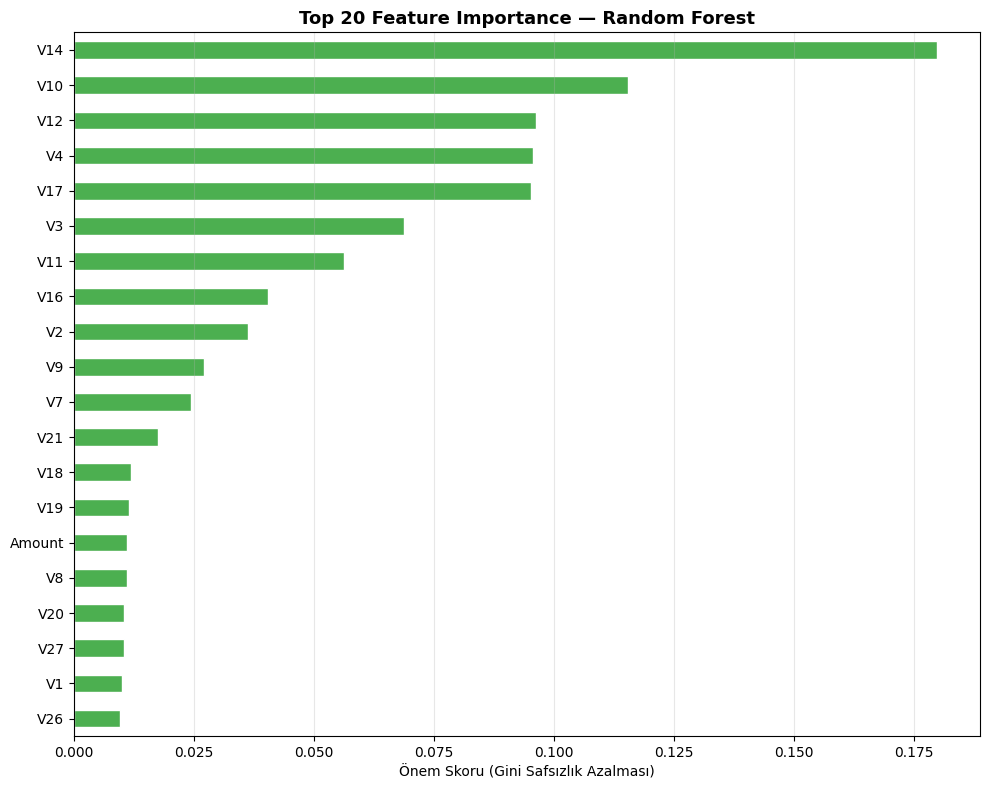

Saved: 11_rf_feature_importance.png

Top 5 feature:
V14    0.179738
V10    0.115455
V12    0.096318
V4     0.095611
V17    0.095131


In [10]:
importances = pd.Series(model.feature_importances_, index=X_train.columns)
top20 = importances.nlargest(20).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
top20.plot(kind='barh', ax=ax, color='#4CAF50', edgecolor='white')
ax.set_xlabel('Önem Skoru (Gini Safsızlık Azalması)')
ax.set_title('Top 20 Feature Importance — Random Forest', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '11_rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 11_rf_feature_importance.png')
print()
print('Top 5 feature:')
print(importances.nlargest(5).to_string())

## 8. Model ve Metrik Kaydet

In [11]:
joblib.dump(model, MODELS_DIR / 'random_forest.pkl')
print('Model kaydedildi: models/random_forest.pkl')

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

metrics = {
    'model'      : 'RandomForestClassifier',
    'step'       : '06_random_forest',
    'class_weight': 'balanced',
    'smote'      : False,
    'n_estimators': RF_CFG['n_estimators'],
    'max_depth'  : RF_CFG['max_depth'],
    'precision'  : round(float(precision), 4),
    'recall'     : round(float(recall),    4),
    'f1'         : round(float(f1),        4),
    'roc_auc'    : round(float(roc_auc),   4),
    'pr_auc'     : round(float(pr_auc),    4),
    'confusion_matrix': {
        'TN': int(tn), 'FP': int(fp),
        'FN': int(fn), 'TP': int(tp)
    }
}

with open(METRICS_DIR / '06_random_forest_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print(json.dumps(metrics, indent=2))
print('\nSaved: 06_random_forest_metrics.json')

Model kaydedildi: models/random_forest.pkl
{
  "model": "RandomForestClassifier",
  "step": "06_random_forest",
  "class_weight": "balanced",
  "smote": false,
  "n_estimators": 100,
  "max_depth": null,
  "precision": 0.9605,
  "recall": 0.7449,
  "f1": 0.8391,
  "roc_auc": 0.9529,
  "pr_auc": 0.8539,
  "confusion_matrix": {
    "TN": 56861,
    "FP": 3,
    "FN": 25,
    "TP": 73
  }
}

Saved: 06_random_forest_metrics.json
